## Question 6: PCA


### Why PCA is Important

Imagine you are working on a dataset related to **image recognition**, where each image is represented by thousands of pixels. For example, consider a dataset of faces where each image has a resolution of 100x100 pixels, leading to 10,000 features (one for each pixel). 

At first, you might think it’s straightforward to classify or analyze these images, but soon you realize that the dataset is **too large and complex** to handle efficiently. The high number of features (10,000 pixels per image) creates computational challenges in terms of processing time and memory usage.

**Here’s where Principal Component Analysis (PCA)** comes into play. PCA helps you reduce the dimensionality of the dataset by selecting the most important features (dimensions) that explain the majority of the variance in the data. 

PCA works by finding the **principal components**, which are new features that are linear combinations of the original features. These components capture the most significant variations in the dataset, allowing you to reduce the number of features while retaining most of the relevant information.

**The Benefit**:  
With PCA, instead of dealing with thousands of features, you can reduce the dataset to just a few **principal components** that explain almost all of the variance in the original data. This drastically improves **computational efficiency** while still maintaining most of the important information.

### PCA Process

The process of calculating the principal components involves a few key steps:

- **Step 1: Covariance Matrix**:  
  First, compute the covariance matrix of the dataset. Covariance helps understand how the features (pixels in the case of images) vary together.
  
- **Step 2: Eigenvalues and Eigenvectors**:  
  The principal components are the **eigenvectors** of the covariance matrix, and each eigenvector is associated with an **eigenvalue**. Eigenvectors represent the directions of maximum variance in the data, and the eigenvalues indicate the magnitude of variance in those directions.
  
- **Step 3: Sorting and Selection**:  
  Sort the eigenvalues in descending order, as the largest eigenvalues correspond to the most important principal components. The top *k* eigenvectors (those associated with the largest eigenvalues) form the reduced dimensionality space.
  
- **What is *k*?**:  
  The number of principal components you choose, *k*, depends on how much variance you want to retain. Typically, you might want to explain at least **85-90% of the total variance** in the dataset using the selected components.

### PCA in Unsupervised Learning

One of the most powerful aspects of PCA is its **unsupervised nature**:  
PCA does not require labeled data to uncover structure.

For example, in the context of breast cancer data:

- When applying PCA on gene expression profiles, samples naturally separated into distinct clusters based on **ER status (ER+ or ER–)**.
- Notably, PCA achieved this separation **without being told** which samples were ER+ or ER–, purely based on variance patterns.

Thus, PCA can reveal biologically meaningful groupings and trends **even when class labels are unavailable or unknown** — making it an essential tool in exploratory data analysis and pattern discovery.



In [1]:
# Loading and PreProcessing the data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip

# File-1: Loading class labels (1 = ER+, 0 = ER-)
# Read the class labels for each sample (ER+ = 1, ER- = 0)
class_labels = pd.read_csv('data/class.tsv', sep='\t', header=None)  # File containing class labels
labels = class_labels[0].values  # Extract the labels into a numpy array

# File-2: Loading gene name mapping
# Read gene mapping data that links gene IDs to gene symbols
with gzip.open('data/columns.tsv.gz', 'rt') as f:
    # Filter out lines that are comments (those starting with '#')
    lines = [line for line in f if not line.startswith('#')]

from io import StringIO
filtered_content = StringIO(''.join(lines))
gene_mapping = pd.read_csv(filtered_content, sep='\t')  # Load gene mapping into a DataFrame

# File-3: Loading gene expression data
with gzip.open('data/filtered.tsv.gz', 'rt') as f:
    expression_data = pd.read_csv(f, sep='\t')  # Read gene expression data into a DataFrame

expression_data.columns = expression_data.columns.astype(str)  
expression_data.columns = expression_data.columns.str.strip()  

print(expression_data.columns)

# Retrieve gene IDs for specific genes (XBP1 and GATA3) from the gene mapping
xbp1_id = 4404  # Known gene ID for XBP1
gata3_id = gene_mapping[gene_mapping['GeneSymbol'] == 'GATA3']['ID'].values[0]  # Get GATA3 gene ID from gene mapping

print(gata3_id)
print('4404' in expression_data.columns)  

xbp1_expression = expression_data[str(xbp1_id)].values  # XBP1 expression values
gata3_expression = expression_data[str(gata3_id)].values  # GATA3 expression values

colors = ['black' if label == 0 else 'red' for label in labels] 


Index(['1', '2', '6', '12', '13', '15', '16', '17', '20', '25',
       ...
       '27622', '27623', '27633', '27634', '27638', '27641', '27642', '27643',
       '27644', '27648'],
      dtype='object', length=16174)
4359
True


In [2]:

# PCA Implementation
def perform_pca(X, k=None):
   
    # Step 1: Centering the data by subtracting the mean of each feature
    x_centered = X - np.mean(X, axis=0)

    # Step 2: Calculate the covariance matrix
    cov_matrix = np.cov(x_centered, rowvar=False)

    # Step 3: Compute eigenvalues and eigenvectors of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # Step 4: Sort eigenvalues and eigenvectors in descending order of eigenvalues
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Step 5: Optionally select the top k eigenvectors if k is specified
    if k is not None:
        eigenvectors = eigenvectors[:, :k]
        eigenvalues = eigenvalues[:k]

    return eigenvectors, eigenvalues, x_centered


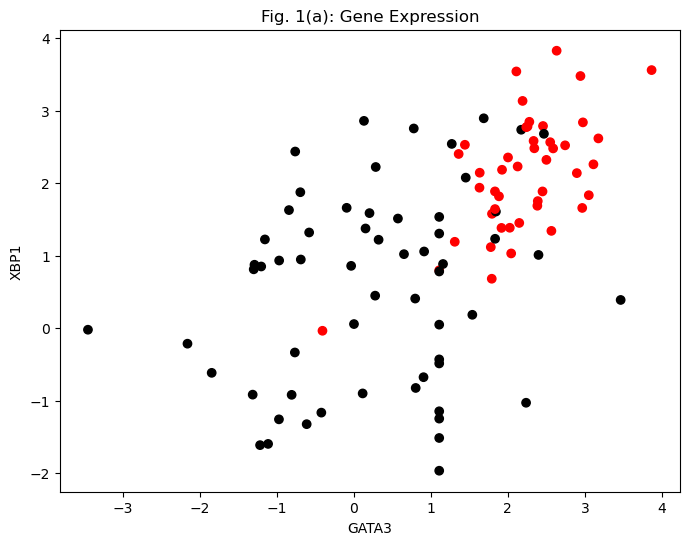

In [3]:
# Figure - 1(a) Scatter plot of xbp1 vs gata3

plt.figure(figsize=(8, 6))
plt.scatter(gata3_expression, xbp1_expression, c=colors)
plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('Fig. 1(a): Gene Expression')
plt.savefig('figure_1a.png')
plt.show()

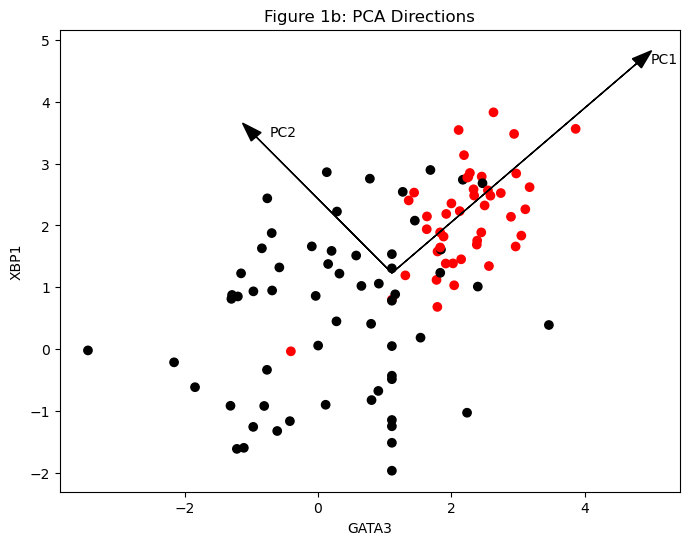

In [4]:
# Figure 1(b)
x = np.column_stack((gata3_expression, xbp1_expression))

eigenvectors, eigenvalues, x_centered = perform_pca(x)
# as can be seen from plot, two principal components are selected
pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

# projections on the principal components - just the matrix multiplication of principal component vector and the original matrix (not the covariance one)
projection_pc1 = np.dot(x_centered, pc1)
projection_pc2 = np.dot(x_centered, pc2)

if np.mean(projection_pc1[labels==1])<np.mean(projection_pc1[labels==0]):
    pc1=-pc1
    projection_pc1=-projection_pc1

if np.mean(projection_pc2[labels == 1]) > np.mean(projection_pc2[labels == 0]) :
    pc2 = -pc2
    projection_pc2 = -projection_pc2

plt.figure(figsize=(8, 6))
plt.scatter(gata3_expression, xbp1_expression, c=colors)

# Plotting the principal components directions
mean_gata3 = np.mean(gata3_expression)
mean_xbp1 = np.mean(xbp1_expression)
plt.arrow(mean_gata3, mean_xbp1, pc1[0]*5, pc1[1]*5, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(mean_gata3, mean_xbp1, pc2[0] * 3, pc2[1] * 3, head_width=0.2, head_length=0.3, fc='black', ec='black')

plt.text(mean_gata3 + pc1[0] * 5 + 0.2, mean_xbp1 + pc1[1] * 5, 'PC1')
plt.text(mean_gata3 + pc2[0] * 3 + 0.2, mean_xbp1 + pc2[1] * 3, 'PC2')

plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('Figure 1b: PCA Directions')
plt.savefig('figure_1b.png')
plt.show()

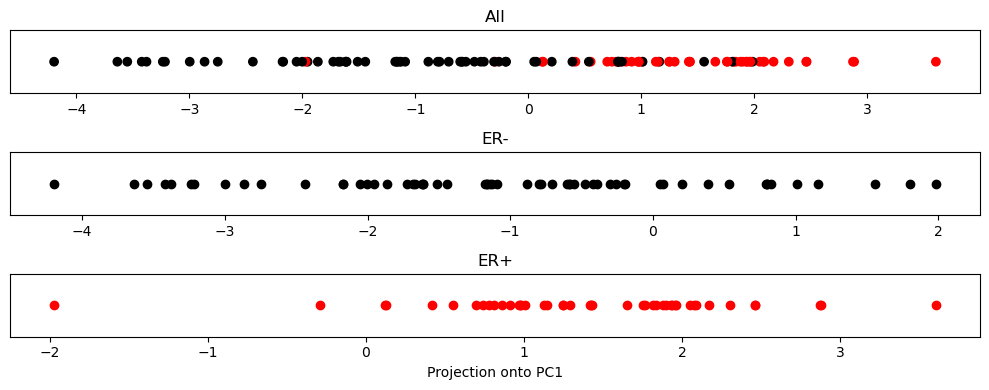

Variance explained by PC1: 0.7792
Variance explained by PC2: 0.2208


In [5]:
# Figure-(c) Projection on PC1

# Separate ER+ and ER- samples
er_pos_pc1 = projection_pc1[labels == 1]
er_neg_pc1 = projection_pc1[labels == 0]

# Create Figure 1c
plt.figure(figsize=(10, 4))

# All samples
plt.subplot(3, 1, 1)
plt.scatter(projection_pc1, np.zeros_like(projection_pc1), c=colors)
plt.yticks([])
plt.title('All')

# ER- samples
plt.subplot(3, 1, 2)
plt.scatter(er_neg_pc1, np.zeros_like(er_neg_pc1), c='black')
plt.yticks([])
plt.title('ER-')

# ER+ samples
plt.subplot(3, 1, 3)
plt.scatter(er_pos_pc1, np.zeros_like(er_pos_pc1), c='red')
plt.yticks([])
plt.title('ER+')
plt.xlabel('Projection onto PC1')

plt.tight_layout()
plt.savefig('figure_1c.png')
plt.show()

# Calculate and print variance explained
print(f"Variance explained by PC1: {eigenvalues[0]/sum(eigenvalues):.4f}")
print(f"Variance explained by PC2: {eigenvalues[1]/sum(eigenvalues):.4f}")


PCA (Principal Component Analysis) is a super useful unsupervised learning technique which helps to reduce the dimensionality of complex data while preserving the most important patterns and preserving maximum information, which is perfect for analyzing gene expression data.

1. It helped us clearly see the separation between ER+ and ER- breast cancer samples.

2. By projecting the data onto the first two principal components, we can visualize complex high-dimensional relationships in a 2D space.

3. The XBP1 and GATA3 genes are important markers for distinguishing between breast cancer types, which is evident from their expression patterns.

4. The first principal component (PC1) captures most of the variance in the data and shows a clear separation between the two cancer subtypes.